# Forward Modelling Notebook: Fluid Propagating Through an Infinite Fracture
# Source: Ricker Wavelet, near field fracture
1. Defining input models
2. Visualising geometry of input models
3. Visualising B-scans
    - Background/ Direct wave
    - Raw
    - Raw - direct wave
4. Creating time-lapse data
    - Comparing changes in amplitude
    - Comparing changes in phase
5. Exporting time-lapse data as gprMax objects


In [1]:
import os
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from gprMax.gprMax import api
from tools.outputfiles_merge import merge_files
from tools.plot_Bscan import get_output_data, mpl_plot

# Infinite Fracture Input Model

Background model

In [41]:
%%writefile Experiment_9/infinite_fracture_background.in

#title: GPR Time-Lapse Subwavelength Resolution - Baseline
#domain: 1.000 0.500 0.0002
#dx_dy_dz: 0.0002 0.0002 0.0002
#time_window: 8e-9

#material: 6 1e-6 1 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Subsurface background model
#box: 0 0 0 1.000 0.400 0.0002 ice

// No pipes or fractures are present

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position (starting at 0.100m, moving 5mm each step)
curr_x = 0.100 + (iteration * 0.005)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_wave')
hertzian_dipole('z', curr_x, 0.400, 0, 'my_wave')
rx(curr_x + 0.020, 0.400, 0)
#end_python:

#python:
if curr_x == 0.500:
    for i in range(1, 100):
        print('#snapshot: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 {} snapshot{}'.format(i*5e-11, i))
#end_python:

#geometry_view: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 infinite_fracture_background n
#messages: y

Baseline (T0)

In [42]:
%%writefile Experiment_9/infinite_fracture_baseline.in

#title: GPR Time-Lapse Subwavelength Resolution - Baseline
#domain: 1.000 0.500 0.0002
#dx_dy_dz: 0.0002 0.0002 0.0002
#time_window: 8e-9

#material: 6 1e-6 1 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Box between the two plastic pipes
#box: 0 0 0 1.000 0.400 0.0002 ice

// Two targets separated by 15mm (Approx lambda/8 at 1.5GHz in sand)

#box:      0.000 0.1990 0.000 1.000 0.2010 0.0002 air

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position (starting at 0.100m, moving 5mm each step)
curr_x = 0.100 + (iteration * 0.005)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_wave')
hertzian_dipole('z', curr_x, 0.400, 0, 'my_wave')
rx(curr_x + 0.020, 0.400, 0)
#end_python:

#python:
if curr_x == 0.500:
    for i in range(1, 100):
        print('#snapshot: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 {} snapshot{}'.format(i*5e-11, i))
#end_python:

#geometry_view: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 infinite_fracture_baseline n
#messages: y

Water propagation (T1,T2,T3)

In [36]:
%%writefile Experiment_9/infinite_fracture_process_1.in

#title: GPR Time-Lapse Subwavelength Resolution - Process
#domain: 1.000 0.500 0.0002
#dx_dy_dz: 0.0002 0.0002 0.0002
#time_window: 8e-9

#material: 6 1e-6 1 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Box between the two plastic pipes
#box: 0 0 0 1.000 0.400 0.0002 ice

// Water infiltrated fracture

#box:      0.000 0.1990 0.000 1.000 0.2010 0.0002 air
#box:      0.000 0.1990 0.000 0.250 0.2010 0.0002 water

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position (starting at 0.100m, moving 5mm each step)
curr_x = 0.100 + (iteration * 0.005)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_wave')
hertzian_dipole('z', curr_x, 0.400, 0, 'my_wave')
rx(curr_x + 0.020, 0.400, 0)
#end_python:

#python:
if curr_x == 0.500:
    for i in range(1, 100):
        print('#snapshot: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 {} snapshot{}'.format(i*5e-11, i))
#end_python:

#geometry_view: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 infinite_fracture_process_1 n
#messages: y

In [43]:
%%writefile Experiment_9/infinite_fracture_process_2.in

#title: GPR Time-Lapse Subwavelength Resolution - Process
#domain: 1.000 0.500 0.0002
#dx_dy_dz: 0.0002 0.0002 0.0002
#time_window: 8e-9

#material: 6 1e-6 1 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Box between the two plastic pipes
#box: 0 0 0 1.000 0.400 0.0002 ice

// Water infiltrated fracture

#box:      0.000 0.1990 0.000 1.000 0.2010 0.0002 air
#box:      0.000 0.1990 0.000 0.500 0.2010 0.0002 water

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position (starting at 0.100m, moving 5mm each step)
curr_x = 0.100 + (iteration * 0.005)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_wave')
hertzian_dipole('z', curr_x, 0.400, 0, 'my_wave')
rx(curr_x + 0.020, 0.400, 0)
#end_python:

#python:
if curr_x == 0.500:
    for i in range(1, 100):
        print('#snapshot: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 {} snapshot{}'.format(i*5e-11, i))
#end_python:

#geometry_view: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 infinite_fracture_process_2 n
#messages: y

In [44]:
%%writefile Experiment_9/infinite_fracture_process_3.in

#title: GPR Time-Lapse Subwavelength Resolution - Process
#domain: 1.000 0.500 0.0002
#dx_dy_dz: 0.0002 0.0002 0.0002
#time_window: 8e-9

#material: 6 1e-6 1 0 ice
#material: 1 0 1 0 air
#material: 80 0.01 1 0 water

// Box
#box: 0 0 0 1.000 0.400 0.0002 ice

// Water infiltrated fracture

#box:      0.000 0.1990 0.000 1.000 0.2010 0.0002 air
#box:      0.000 0.1990 0.000 0.750 0.2010 0.0002 water

#python:
from gprMax.input_cmd_funcs import *

# current_model_run starts at 1 and goes up to the -n value
iteration = current_model_run - 1  # Offset to start at 0

# Calculate current x-position (starting at 0.100m, moving 5mm each step)
curr_x = 0.100 + (iteration * 0.005)

# Place exactly ONE source and ONE receiver
waveform('ricker', 1.0, 1.5e9, 'my_wave')
hertzian_dipole('z', curr_x, 0.400, 0, 'my_wave')
rx(curr_x + 0.020, 0.400, 0)
#end_python:

#python:
if curr_x == 0.500:
    for i in range(1, 100):
        print('#snapshot: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 {} snapshot{}'.format(i*5e-11, i))
#end_python:

#geometry_view: 0 0 0 1.000 0.500 0.0002 0.0002 0.0002 0.0002 infinite_fracture_process_3 n
#messages: y

Run for 160 traces

# Calculating aperture and discretisation

In [55]:
materials = {
    'ice': {'epsilon_r': 6, 'sigma': 1e-6, 'mu_r': 1, 'rho': 0},
    'air': {'epsilon_r': 1, 'sigma': 0, 'mu_r': 1, 'rho': 0},
    'water': {'epsilon_r': 80, 'sigma': 0.01, 'mu_r': 1, 'rho': 0}
}

frequency = 1.5e9  # Hz
c = 3e8  #  m/s
epsilon_r_ice = materials['water']['epsilon_r']
wavelength_ice = c / (frequency * np.sqrt(epsilon_r_ice))
print(f"Wavelength in ice at 1.5GHz: {wavelength_ice:.3f} m = {wavelength_ice*1000:.0f} mm")

maximum_fracture_width = wavelength_ice / 4
print(f"Maximum fracture width for subwavelength resolution: {maximum_fracture_width:.4f} m = {maximum_fracture_width*1000:.1f} mm")

sub_wavelength_width = wavelength_ice / 11
print(f"Subwavelength fracture width (lambda/8): {sub_wavelength_width:.4f} m = {sub_wavelength_width*1000:.1f} mm")

y_top = 0.200 + (sub_wavelength_width / 2)
y_bottom = 0.200 - (sub_wavelength_width / 2)
print(f"Fracture boundaries for subwavelength width: y_top = {y_top:.4f} m, y_bottom = {y_bottom:.4f} m")

dx_dy_dz = sub_wavelength_width / 10
print(f"Recommended grid resolution (dx, dy, dz): {dx_dy_dz:.5f} m = {dx_dy_dz*1000:.2f} mm")

# After running the forward simulation

Merge the files after running the forward simulation to create B-scans and remove any vti files created in the process

In [2]:
# background_filename = r'Experiment_9\infinite_fracture_background'
# baseline_filename   = r'Experiment_9\infinite_fracture_baseline'
# process_1_filename  = r'Experiment_9\infinite_fracture_process_1'
# process_2_filename  = r'Experiment_9\infinite_fracture_process_2'
# process_3_filename  = r'Experiment_9\infinite_fracture_process_3'

# merge_files(background_filename, removefiles=True)
# merge_files(baseline_filename,   removefiles=True)
# merge_files(process_1_filename,  removefiles=True)
# merge_files(process_2_filename,  removefiles=True)
# merge_files(process_3_filename,  removefiles=True)


# # Remove geometry visualization files
# for file in os.listdir('Experiment_9'):
#     if file.startswith('infinite_fracture_background') and file.endswith('.vti') and file != 'infinite_fracture_background.vti':
#         os.remove(os.path.join('Experiment_9', file))

# for file in os.listdir('Experiment_9'):
#     if file.startswith('infinite_fracture_process') and file.endswith('.vti') and file != 'infinite_fracture_process.vti':
#         os.remove(os.path.join('Experiment_9', file))

# for file in os.listdir('Experiment_9'):
#     if file.startswith('infinite_fracture_baseline') and file.endswith('.vti') and file != 'infinite_fracture_baseline.vti':
#         os.remove(os.path.join('Experiment_9', file))

Create vti files to visualise the model parameters

In [26]:

# background_input = r'Experiment_9\infinite_fracture_background.in'
# baseline_input   = r'Experiment_9\infinite_fracture_baseline.in'
# process_1_input  = r'Experiment_9\infinite_fracture_process_1.in'
# process_2_input  = r'Experiment_9\infinite_fracture_process_2.in'
# process_3_input  = r'Experiment_9\infinite_fracture_process_3.in'

# api(background_input, n=1, geometry_only=True)
# api(baseline_input,   n=1, geometry_only=True)
# api(process_1_input,  n=1, geometry_only=True)
# api(process_2_input,  n=1, geometry_only=True)
# api(process_3_input,  n=1, geometry_only=True)



=== Electromagnetic modelling software based on the Finite-Difference Time-Domain (FDTD) method 

    www.gprmax.com   __  __
     __ _ _ __  _ __|  \/  | __ ___  __
    / _` | '_ \| '__| |\/| |/ _` \ \/ /
   | (_| | |_) | |  | |  | | (_| |>  <
    \__, | .__/|_|  |_|  |_|\__,_/_/\_\\
    |___/|_|
                     v3.1.7 (Big Smoke)

 Copyright (C) 2015-2023: The University of Edinburgh
 Authors: Craig Warren and Antonis Giannopoulos

 gprMax is free software: you can redistribute it and/or modify it under the
  terms of the GNU General Public License as published by the Free Software
  Foundation, either version 3 of the License, or (at your option) any later
  version.
 gprMax is distributed in the hope that it will be useful, but WITHOUT ANY
  WARRANTY; without even the implied warranty of MERCHANTABILITY or FITNESS FOR
  A PARTICULAR PURPOSE.  See the GNU General Public License for more details.
 You should have received a copy of the GNU General Public License along with
  gp

Retrieve Data and Take Timelapse

In [34]:
infinite_fracture_background_data = r'Experiment_9\infinite_fracture_background_merged.out'
infinite_fracture_baseline_data   = r'Experiment_9\infinite_fracture_baseline_merged.out'
infinite_fracture_process_1_data  = r'Experiment_9\infinite_fracture_process_1_merged.out'
infinite_fracture_process_2_data  = r'Experiment_9\infinite_fracture_process_2_merged.out'
infinite_fracture_process_3_data  = r'Experiment_9\infinite_fracture_process_3_merged.out'
rxnumber = 1
rxcomponent = 'Ez'

output_infinite_fracture_background, dt = get_output_data(infinite_fracture_background_data, rxnumber, rxcomponent)
output_infinite_fracture_baseline,   dt = get_output_data(infinite_fracture_baseline_data,   rxnumber, rxcomponent)
output_infinite_fracture_process_1,  dt = get_output_data(infinite_fracture_process_1_data,  rxnumber, rxcomponent)
output_infinite_fracture_process_2,  dt = get_output_data(infinite_fracture_process_2_data,  rxnumber, rxcomponent)
output_infinite_fracture_process_3,  dt = get_output_data(infinite_fracture_process_3_data,  rxnumber, rxcomponent)

In [35]:
receiver_positions = np.arange(output_infinite_fracture_baseline.shape[1]) * 0.005 + 0.100 + 0.020  # rx positions = source positions + 0.020 m offset
time_axis          = np.arange(output_infinite_fracture_baseline.shape[0]) * dt

extent = [0, output_infinite_fracture_baseline.shape[1], time_axis[-1]*1e9, time_axis[0]*1e9]  # in (m,ns)

In [36]:
# remove direct wave: output - background
baseline_no_direct  = output_infinite_fracture_baseline  - output_infinite_fracture_background
process_1_no_direct = output_infinite_fracture_process_1 - output_infinite_fracture_background
process_2_no_direct = output_infinite_fracture_process_2 - output_infinite_fracture_background
process_3_no_direct = output_infinite_fracture_process_3 - output_infinite_fracture_background

# time-lapse differences
diff_1 = process_1_no_direct - baseline_no_direct
diff_2 = process_2_no_direct - process_1_no_direct
diff_3 = process_3_no_direct - process_2_no_direct

# save to numPy files for later use
np.save('Experiment_9/infinite_fracture_receiver_positions.npy', receiver_positions)
np.save('Experiment_9/infinite_fracture_time_axis.npy', time_axis)
np.save('Experiment_9/infinite_fracture_extent.npy', extent)

np.save('Experiment_9/infinite_fracture_background.npy', output_infinite_fracture_background)
np.save('Experiment_9/infinite_fracture_baseline.npy',   output_infinite_fracture_baseline)
np.save('Experiment_9/infinite_fracture_process_1.npy',  output_infinite_fracture_process_1)
np.save('Experiment_9/infinite_fracture_process_2.npy',  output_infinite_fracture_process_2)
np.save('Experiment_9/infinite_fracture_process_3.npy',  output_infinite_fracture_process_3)

np.save('Experiment_9/infinite_fracture_diff_1.npy', diff_1)
np.save('Experiment_9/infinite_fracture_diff_2.npy', diff_2)
np.save('Experiment_9/infinite_fracture_diff_3.npy', diff_3)


# Conceptual Model

Model Geometry

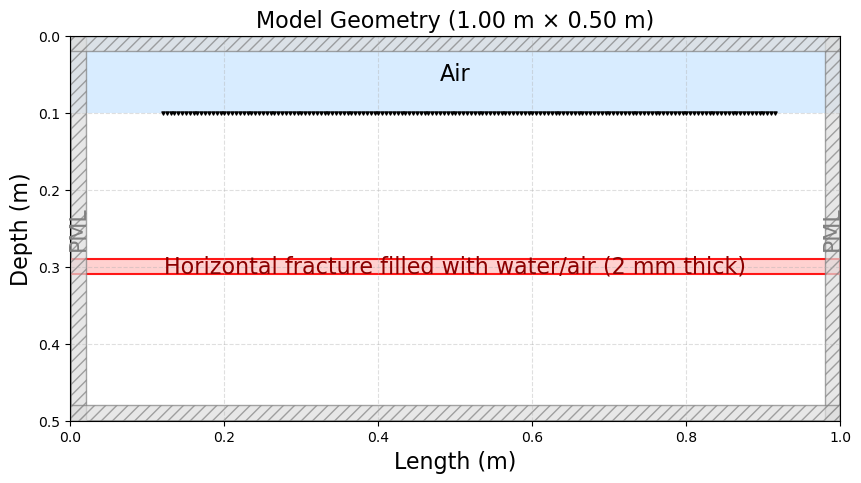

In [112]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Model dimensions
length = 1.0   # x-length (m)
depth  = 0.5   # y-depth (m)
upper_layer_thickness = 0.1  # m
fracture_y0 = depth - 0.190
fracture_y1 = depth - 0.210
pml_thickness = 0.02  # m

# Receiver positions
receiver_positions = np.arange(160) * 0.005 + 0.100 + 0.020
receiver_y = 0.100

fig, ax = plt.subplots(figsize=(10, 5))

# Outer box (model domain)
outer = Rectangle((0, 0), length, depth, fill=False, edgecolor='black', linewidth=2)
ax.add_patch(outer)

# Upper layer (top 0.100 m)
upper = Rectangle((0, 0), length, upper_layer_thickness, facecolor='#cfe8ff', edgecolor='none', alpha=0.8)
ax.add_patch(upper)

# Horizontal box between y=0.190 and y=0.210 across full length
fracture = Rectangle((0, fracture_y0), length, fracture_y1 - fracture_y0,
                     facecolor='#ffcccb', edgecolor='red', linewidth=1.5, alpha=0.9)
ax.add_patch(fracture)

# PMLs (0.02 m into the domain on all sides)
pml_style = dict(facecolor='#dddddd', edgecolor='gray', alpha=0.7, hatch='///')
# Left PML
ax.add_patch(Rectangle((0, 0), pml_thickness, depth, **pml_style))
# Right PML
ax.add_patch(Rectangle((length - pml_thickness, 0), pml_thickness, depth, **pml_style))
# Top PML
ax.add_patch(Rectangle((0, 0), length, pml_thickness, **pml_style))
# Bottom PML
ax.add_patch(Rectangle((0, depth - pml_thickness), length, pml_thickness, **pml_style))



# Annotations
ax.text(0.5, upper_layer_thickness / 2, 'Air',
        ha='center', va='center', fontsize=16, color='black')
ax.text(0.5, (fracture_y0 + fracture_y1) / 2, 'Horizontal fracture filled with water/air (2 mm thick)',
        ha='center', va='center', fontsize=16, color='darkred')
ax.text(length - pml_thickness / 2, depth / 2, 'PML', ha='center', va='center', fontsize=16, color='gray', rotation=90)
ax.text(pml_thickness / 2, depth / 2, 'PML', ha='center', va='center', fontsize=16, color='gray', rotation=90)

# Receiver positions (triangles)
ax.scatter(receiver_positions, np.full_like(receiver_positions, receiver_y),
        marker='v', s=5, color='black', zorder=5, label='Receivers')

ax.set_title('Model Geometry (1.00 m × 0.50 m)', fontsize=16)
ax.set_xlabel('Length (m)', fontsize=16)
ax.set_ylabel('Depth (m)', fontsize=16)
ax.set_xlim(0, length)
ax.set_ylim(depth, 0)  # invert to show depth downward
ax.set_aspect('equal', adjustable='box')
ax.grid(True, linestyle='--', alpha=0.4)

# save image
path = 'Images_Experiment_9\\Introduction\\Model_Geometry.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()

Fluid Propagation

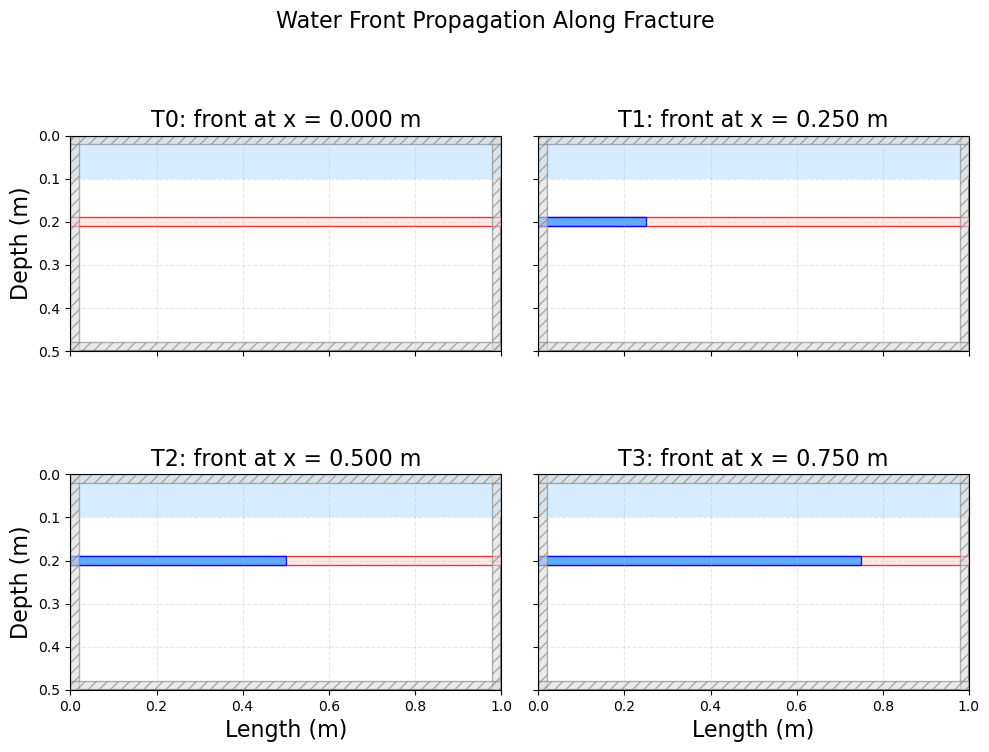

In [113]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Model dimensions
length = 1.0   # x-length (m)
depth  = 0.5   # y-depth (m)
upper_layer_thickness = 0.1  # m
fracture_y0 = 0.190
fracture_y1 = 0.210
pml_thickness = 0.02  # m

fronts = [0.0, 0.250, 0.500, 0.750]
labels = ['T0', 'T1', 'T2', 'T3']

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
axes = axes.flatten()

for ax, front, label in zip(axes, fronts, labels):
    # Domain
    ax.add_patch(Rectangle((0, 0), length, depth, fill=False, edgecolor='black', linewidth=1.5))


    # Upper layer (top 0.100 m)
    ax.add_patch(Rectangle((0, 0), length, upper_layer_thickness,
                           facecolor='#cfe8ff', edgecolor='none', alpha=0.8))

    # Fracture zone
    ax.add_patch(Rectangle((0, fracture_y0), length, fracture_y1 - fracture_y0,
                           facecolor='#ffe6e6', edgecolor='red', linewidth=1.0, alpha=0.8))

    # Water front (filled portion)
    if front > 0:
        ax.add_patch(Rectangle((0, fracture_y0), front, fracture_y1 - fracture_y0,
                               facecolor='#4da3ff', edgecolor='blue', alpha=0.9))
        
    # PMLs (0.02 m into the domain on all sides)
    pml_style = dict(facecolor='#dddddd', edgecolor='gray', alpha=0.6, hatch='///')
    ax.add_patch(Rectangle((0, 0), pml_thickness, depth, **pml_style))
    ax.add_patch(Rectangle((length - pml_thickness, 0), pml_thickness, depth, **pml_style))
    ax.add_patch(Rectangle((0, 0), length, pml_thickness, **pml_style))
    ax.add_patch(Rectangle((0, depth - pml_thickness), length, pml_thickness, **pml_style))

    ax.set_title(f'{label}: front at x = {front:.3f} m', fontsize=16)
    ax.set_xlim(0, length)
    ax.set_ylim(depth, 0)  # depth downward
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.3)

for ax in axes[::2]:
    ax.set_ylabel('Depth (m)', fontsize=16)
for ax in axes[2:]:
    ax.set_xlabel('Length (m)', fontsize=16)

plt.suptitle('Water Front Propagation Along Fracture', fontsize=16)
plt.tight_layout()


# save image
path = 'Images_Experiment_9\\Introduction\\Water_Front_Propagation.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()


Material Properties

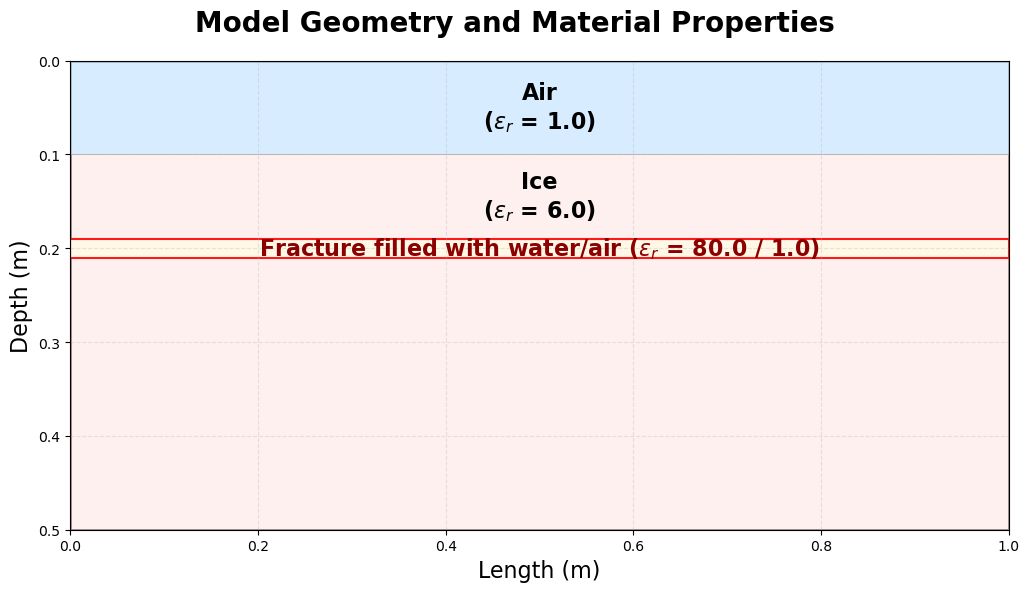

In [114]:
# Remove the gridspec and recreate figure with single subplot
fig = plt.figure(figsize=(12, 6))
ax_geom = fig.add_subplot(111)

# Model dimensions
length = 1.0
depth = 0.5
upper_layer_thickness = 0.1
fracture_y0 = 0.190
fracture_y1 = 0.210

# Domain boundary
ax_geom.add_patch(Rectangle((0, 0), length, depth, fill=False, edgecolor='black', linewidth=2))

# Upper layer (Air)
ax_geom.add_patch(Rectangle((0, 0), length, upper_layer_thickness, 
                           facecolor='#cfe8ff', edgecolor='black', linewidth=0.5, alpha=0.8))

# Background (Ice)
ax_geom.add_patch(Rectangle((0, upper_layer_thickness), length, depth - upper_layer_thickness,
                           facecolor='#ffe6e6', edgecolor='none', alpha=0.6))

# Fracture zone
ax_geom.add_patch(Rectangle((0, fracture_y0), length, fracture_y1 - fracture_y0,
                           facecolor='#fff9e6', edgecolor='red', linewidth=1.5, alpha=0.9))

# Annotations
ax_geom.text(0.5, upper_layer_thickness / 2, 'Air\n($ε_r$ = 1.0)', 
            ha='center', va='center', fontsize=16, weight='bold')
ax_geom.text(0.5, (upper_layer_thickness + fracture_y0) / 2, 'Ice\n($ε_r$ = 6.0)', 
            ha='center', va='center', fontsize=16, weight='bold')
ax_geom.text(0.5, (fracture_y0 + fracture_y1) / 2, 'Fracture filled with water/air ($ε_r$ = 80.0 / 1.0)', 
            ha='center', va='center', fontsize=16, weight='bold', color='darkred')

ax_geom.set_xlabel('Length (m)', fontsize=16)
ax_geom.set_ylabel('Depth (m)', fontsize=16)
ax_geom.set_xlim(0, length)
ax_geom.set_ylim(depth, 0)
ax_geom.set_aspect('equal', adjustable='box')
ax_geom.grid(True, linestyle='--', alpha=0.3)

plt.suptitle('Model Geometry and Material Properties', fontsize=20, weight='bold', y=0.98)
plt.tight_layout()

# save image
path = 'Images_Experiment_9\\Methodology\\Material_Properties.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()


# Snapshot Visualization

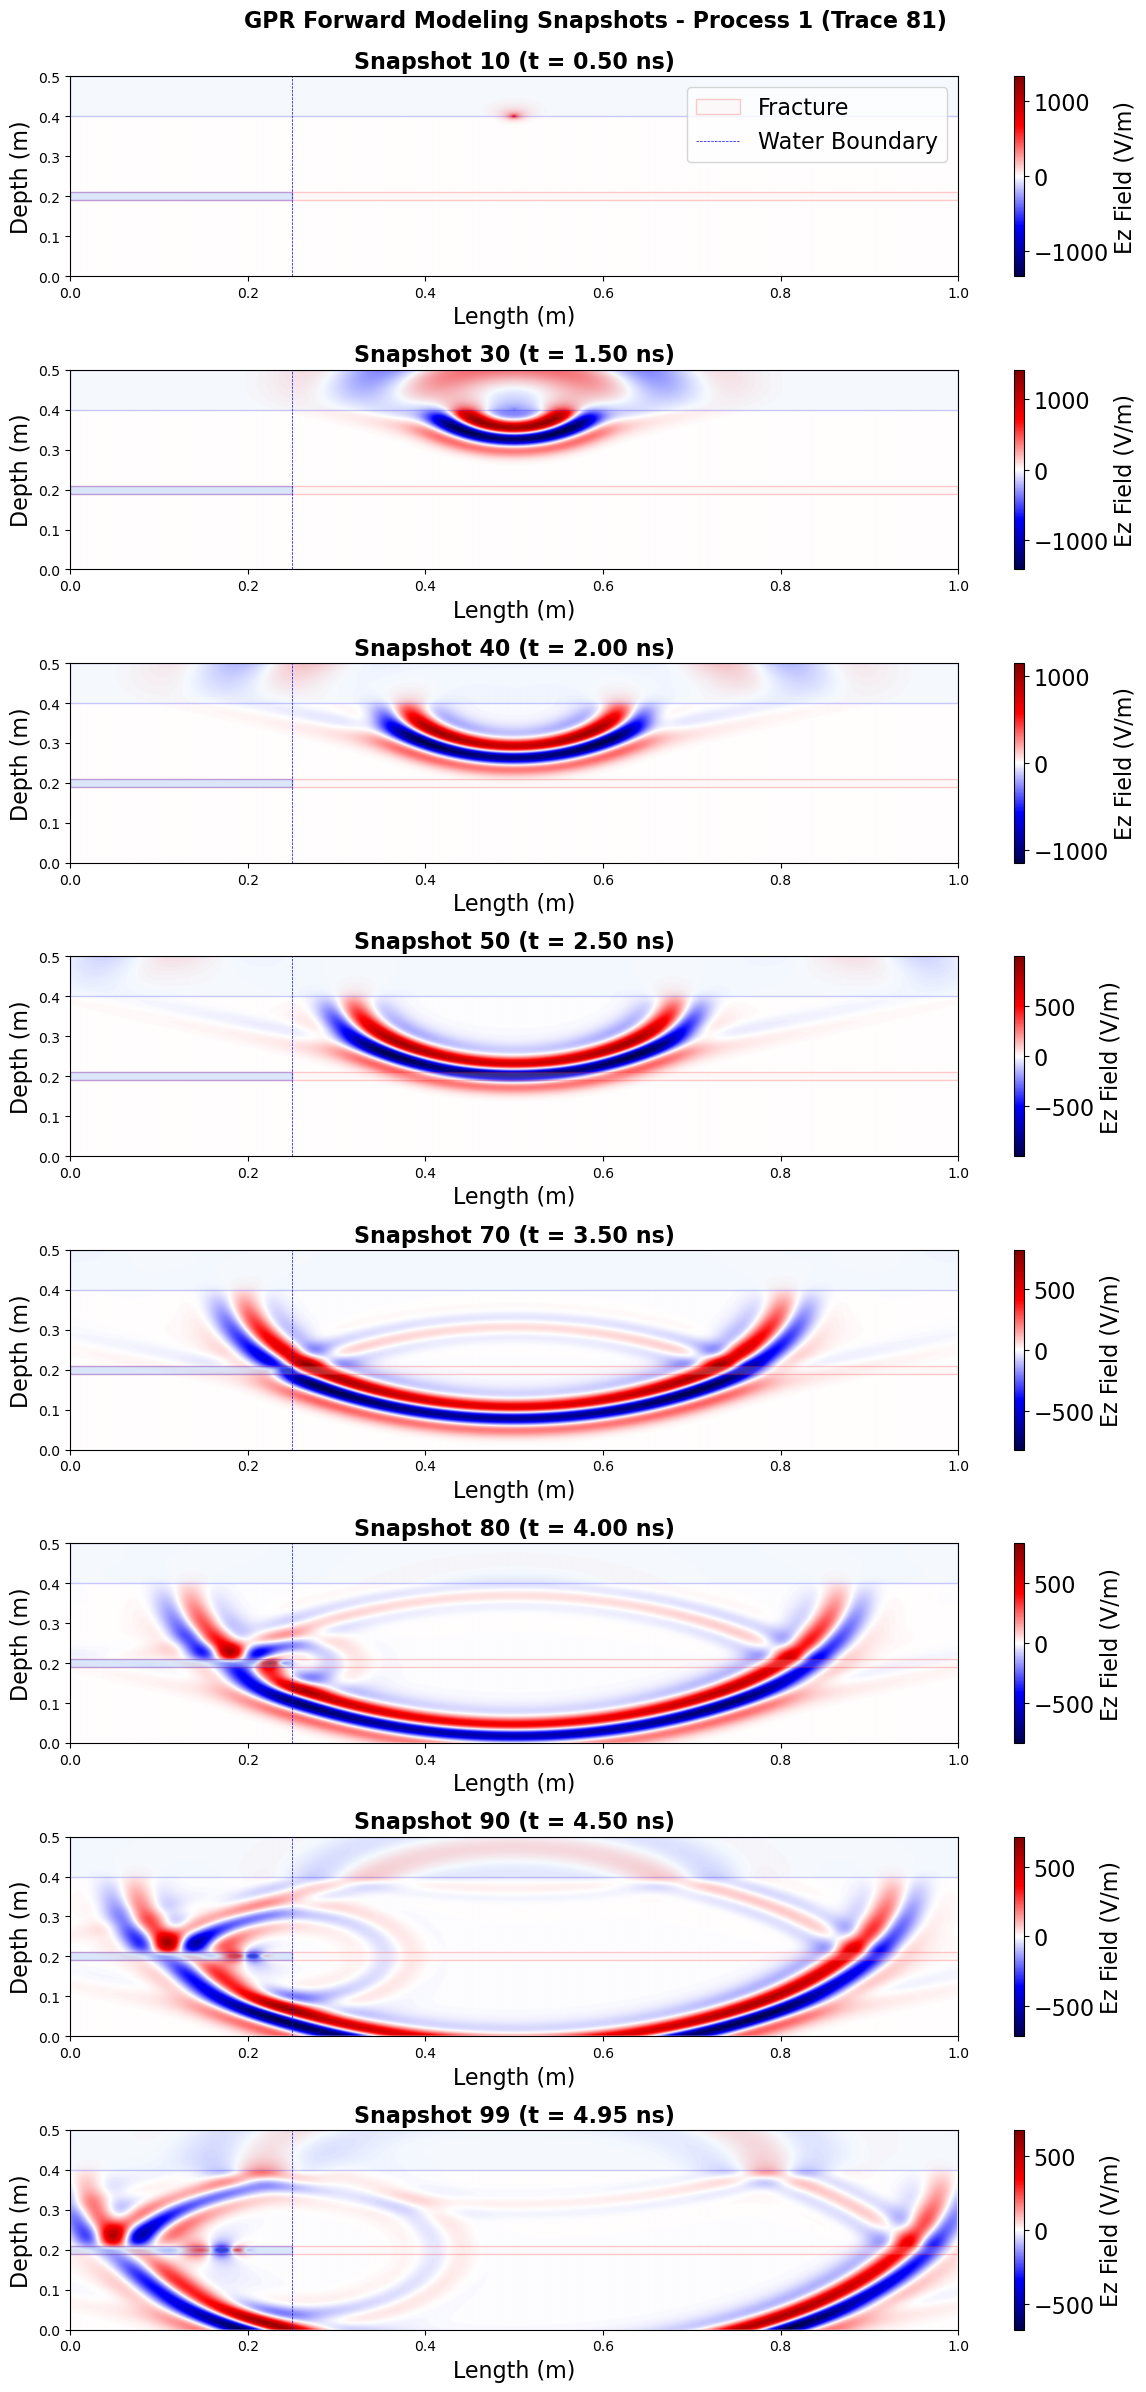

In [115]:
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Model dimensions
length = 1.0   # x-length (m)
depth  = 0.5   # y-depth (m)
upper_layer_thickness = 0.1  # m
fracture_y0 = 0.190
fracture_y1 = 0.210
water_boundary_x = 0.250  # m

# Path to snapshot folder
snapshot_folder = r'C:\Users\Administrator\OneDrive\Data B\School\GP2\Research Project\GPRMax\Experiment_9\infinite_fracture_process_1_snaps81'

# Select 8 evenly spaced snapshots from the 100 available
snapshot_indices = [10, 30, 40, 50, 70, 80, 90, 99]

# Create a figure with 8 subplots arranged vertically
fig, axes = plt.subplots(8, 1, figsize=(12, 24))

for i, (ax, snap_num) in enumerate(zip(axes, snapshot_indices)):
    # Read the VTI file
    snapshot_path = f'{snapshot_folder}\\snapshot{snap_num}.vti'
    mesh = pv.read(snapshot_path)
    
    # Get the mesh dimensions
    dims = mesh.dimensions
    
    # Check available field names
    field_name = 'E-field'  # This is a vector field with 3 components (Ex, Ey, Ez)
    
    if field_name in mesh.array_names:
        data = mesh[field_name]
        
        # E-field is a 3-component vector field
        # Reshape to get the grid: (nx-1) * (ny-1) * (nz-1) points, each with 3 components
        num_cells = (dims[0]-1) * (dims[1]-1) * (dims[2]-1)
        
        # Extract Ez component (index 2)
        if data.shape[1] == 3:  # Vector field with 3 components
            Ez_data = data[:, 2]  # Get z-component
        else:
            Ez_data = data.flatten()
        
        # Reshape to 2D grid (for 2D simulation, z-dimension is 1)
        data_2d = Ez_data.reshape(dims[1]-1, dims[0]-1)
        
        # Plot the data (without transpose)
        im = ax.imshow(data_2d, aspect='auto', cmap='seismic', origin='lower',
                      vmin=-np.abs(data_2d).max(), vmax=np.abs(data_2d).max(),
                      extent=[0, length, 0, depth])
        
        # Calculate time for this snapshot (5e-11 s per snapshot)
        time_ns = snap_num * 5e-11 * 1e9
        
        ax.set_title(f'Snapshot {snap_num} (t = {time_ns:.2f} ns)', fontsize=16, weight='bold')
        ax.set_xlabel('Length (m)', fontsize=16)
        ax.set_ylabel('Depth (m)', fontsize=16)
        
        # Upper layer (top)
        ax.add_patch(Rectangle((0, depth - upper_layer_thickness), length, upper_layer_thickness,
                               facecolor='#cfe8ff', edgecolor='blue', alpha=0.2))
        
        # Fracture zone
        ax.add_patch(Rectangle((0, fracture_y0), length, fracture_y1 - fracture_y0,
                               facecolor='#ffe6e6', edgecolor='red', linewidth=1.0, alpha=0.2,
                               label='Fracture' if i == 0 else ''))
        
        # Water boundary line at x = 0.250 m
        ax.axvline(x=water_boundary_x, color='blue', linestyle='--', linewidth=0.5,
                  label='Water Boundary' if i == 0 else '')
        
        # Water front (filled portion)
        if water_boundary_x > 0:
            ax.add_patch(Rectangle((0, fracture_y0), water_boundary_x, fracture_y1 - fracture_y0,
                                facecolor='#4da3ff', edgecolor='blue', alpha=0.2))
        
        # Add legend to first subplot only
        if i == 0:
            ax.legend(loc='upper right', fontsize=16)
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax, label='Ez Field (V/m)')
        cbar.ax.tick_params(labelsize=16)
        cbar.set_label('Ez Field (V/m)', fontsize=16)
        
    else:
        ax.text(0.5, 0.5, f'Field {field_name} not found\nAvailable: {mesh.array_names}',
               ha='center', va='center', transform=ax.transAxes)

plt.suptitle('GPR Forward Modeling Snapshots - Process 1 (Trace 81)', fontsize=16, weight='bold', y=0.995)
plt.tight_layout()

# save image
path = 'Images_Experiment_9\\Results\\Raw\\Snapshots_Process_1.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()

# B-scan Visualisation

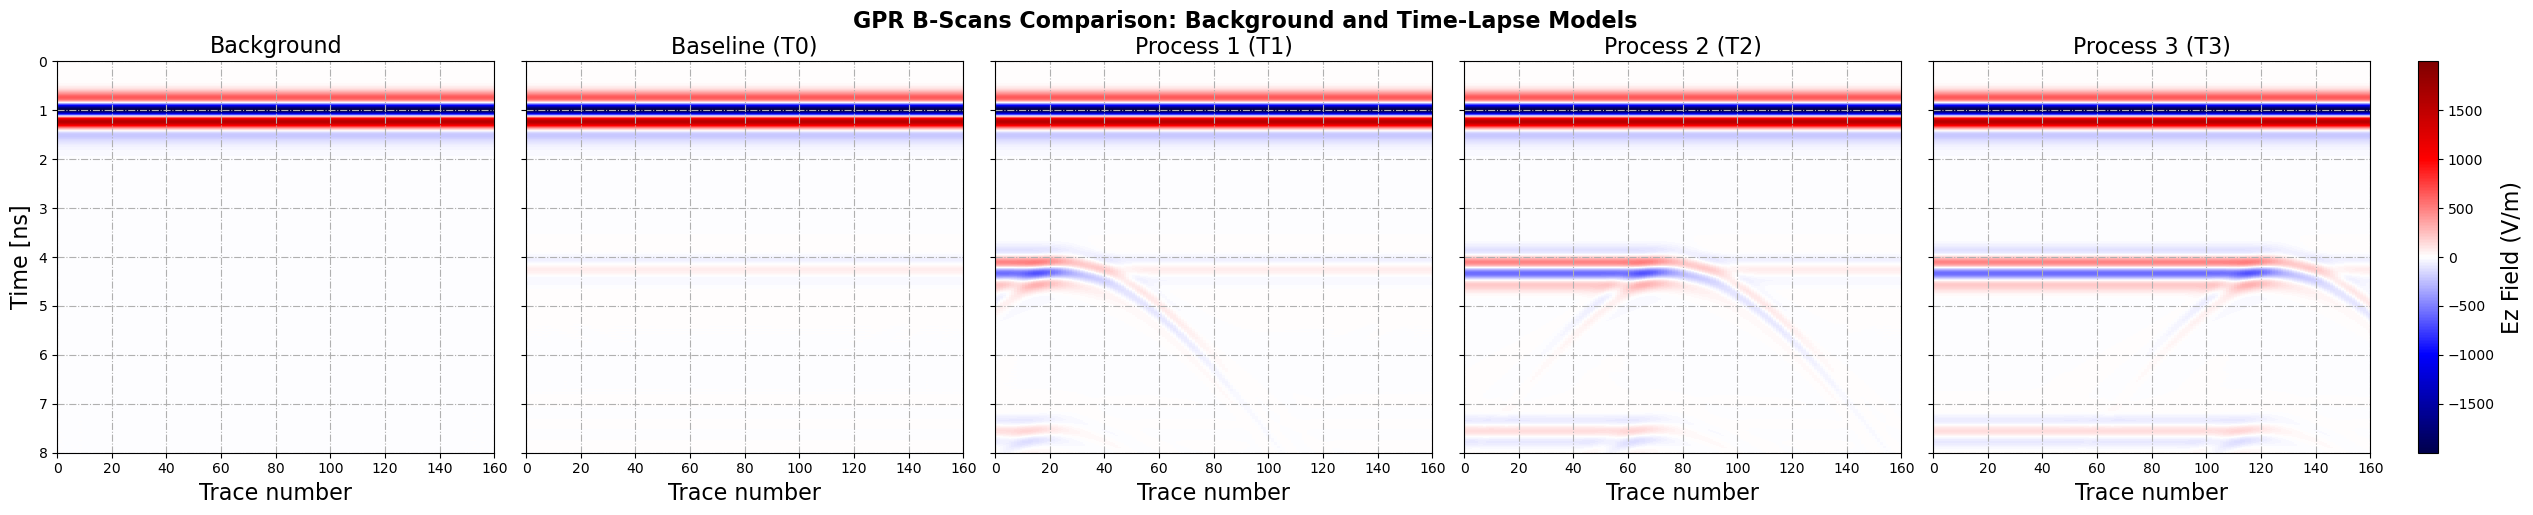

In [116]:
# Plot all B-scans side by side for comparison
fig, axes = plt.subplots(1, 5, figsize=(25, 5), facecolor='w', edgecolor='w', sharex=True, sharey=True)

data_all = [
    ("Background", output_infinite_fracture_background),
    ("Baseline (T0)", output_infinite_fracture_baseline),
    ("Process 1 (T1)", output_infinite_fracture_process_1),
    ("Process 2 (T2)", output_infinite_fracture_process_2),
    ("Process 3 (T3)", output_infinite_fracture_process_3),
]

# Use common color scaling across all plots
vmin = -np.amax([np.abs(d).max() for _, d in data_all])
vmax = np.amax([np.abs(d).max() for _, d in data_all])

for i, (title, data) in enumerate(data_all):
    ax = axes[i]
    im = ax.imshow(data, aspect='auto', cmap='seismic', extent=extent, interpolation='nearest',
                   vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Trace number', fontsize=16)
    if i == 0:
        ax.set_ylabel('Time [ns]', fontsize=16)
    ax.grid(which='both', axis='both', linestyle='-.')

plt.tight_layout()

cbar1 = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)

plt.suptitle('GPR B-Scans Comparison: Background and Time-Lapse Models', fontsize=16, weight='bold', y=1.02)

# save image
path = 'Images_Experiment_9\\Results\\Raw\\All_B-scans.png'
plt.savefig(fname=path, bbox_inches='tight')

plt.show()


B-scans with no direct wave

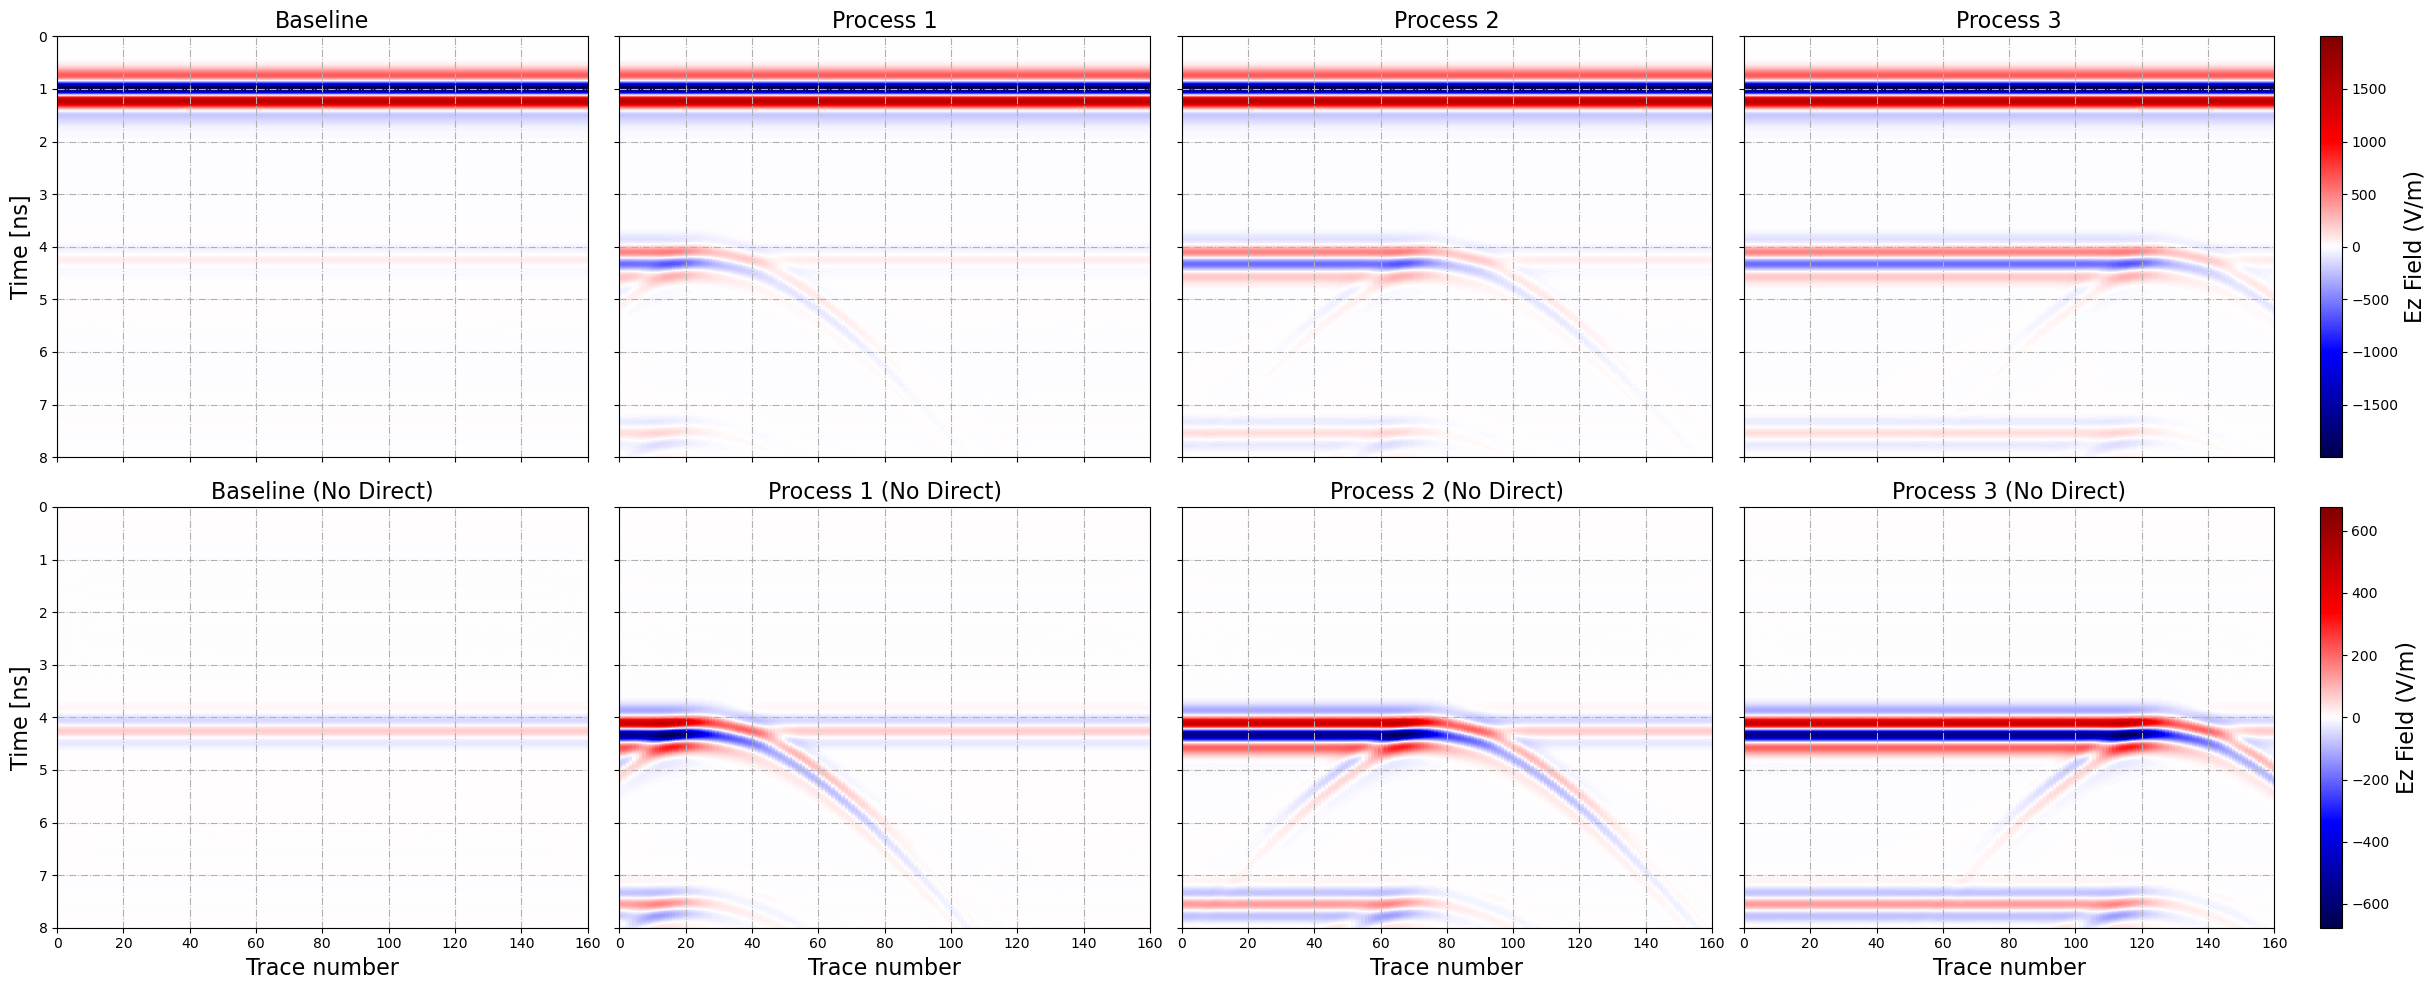

In [111]:

# Plotting: Baseline/Processes and No-Direct versions (2 rows x 4 columns)
fig, axes = plt.subplots(2, 4, figsize=(24, 10), facecolor='w', edgecolor='w', sharex=True, sharey=True)

data_top = [
    ("Baseline",   output_infinite_fracture_baseline),
    ("Process 1",  output_infinite_fracture_process_1),
    ("Process 2",  output_infinite_fracture_process_2),
    ("Process 3",  output_infinite_fracture_process_3),
]

data_bottom = [
    ("Baseline (No Direct)",  baseline_no_direct),
    ("Process 1 (No Direct)", process_1_no_direct),
    ("Process 2 (No Direct)", process_2_no_direct),
    ("Process 3 (No Direct)", process_3_no_direct),
]

# Common color scaling per row
vmin_top = -np.amax([np.abs(d).max() for _, d in data_top])
vmax_top =  np.amax([np.abs(d).max() for _, d in data_top])

vmin_bottom = -np.amax([np.abs(d).max() for _, d in data_bottom])
vmax_bottom =  np.amax([np.abs(d).max() for _, d in data_bottom])

# Top row
for i, (title, data) in enumerate(data_top):
    ax = axes[0, i]
    im = ax.imshow(data, aspect='auto', cmap='seismic', extent=extent, interpolation='nearest',
                   vmin=vmin_top, vmax=vmax_top)
    ax.set_title(title, fontsize=16)
    ax.grid(which='both', axis='both', linestyle='-.')
    if i == 0:
        ax.set_ylabel('Time [ns]', fontsize=16)

# Bottom row
for i, (title, data) in enumerate(data_bottom):
    ax = axes[1, i]
    im2 = ax.imshow(data, aspect='auto', cmap='seismic', extent=extent, interpolation='nearest',
                    vmin=vmin_bottom, vmax=vmax_bottom)
    ax.set_title(title, fontsize=16)
    ax.grid(which='both', axis='both', linestyle='-.')
    if i == 0:
        ax.set_ylabel('Time [ns]', fontsize=16)
    ax.set_xlabel('Trace number', fontsize=16)

plt.tight_layout()

cbar1 = fig.colorbar(im, ax=axes[0, :], fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)
cbar2 = fig.colorbar(im2, ax=axes[1, :], fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)


# save image
path = 'Images_Experiment_9\\Results\\Processing\\B-scans_with_and_without_direct_wave.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()

# Plotting: time-lapse

Amplitude change

In [101]:
# absolute min-max scaled time-lapse differences
baseline_no_direct

diff_1_scaled_abs = (diff_1 - np.min(diff_1)) / (np.max(diff_1) - np.min(diff_1)) * 2 - 1
diff_2_scaled_abs = (diff_2 - np.min(diff_2)) / (np.max(diff_2) - np.min(diff_2)) * 2 - 1
diff_3_scaled_abs = (diff_3 - np.min(diff_3)) / (np.max(diff_3) - np.min(diff_3)) * 2 - 1

# min-max scaled time-lapse differences
min_val = np.min(np.abs(baseline_no_direct - process_1_no_direct))
max_val = np.max(np.abs(baseline_no_direct - process_1_no_direct))
norm = plt.Normalize(vmin=min_val, vmax=max_val)

diff_1_scaled = norm(np.abs(diff_1))


min_val = np.min(np.abs(process_1_no_direct - process_2_no_direct))
max_val = np.max(np.abs(process_1_no_direct - process_2_no_direct))
norm = plt.Normalize(vmin=min_val, vmax=max_val)

diff_2_scaled = norm(np.abs(diff_2))


min_val = np.min(np.abs(process_2_no_direct - process_3_no_direct))
max_val = np.max(np.abs(process_2_no_direct - process_3_no_direct))
norm = plt.Normalize(vmin=min_val, vmax=max_val)

diff_3_scaled = norm(np.abs(diff_3))

# save to numPy files for later use
np.save('Experiment_9/infinite_fracture_diff_1_scaled.npy',  np.array(diff_1_scaled))
np.save('Experiment_9/infinite_fracture_diff_2_scaled.npy',  np.array(diff_2_scaled))
np.save('Experiment_9/infinite_fracture_diff_3_scaled.npy',  np.array(diff_3_scaled))

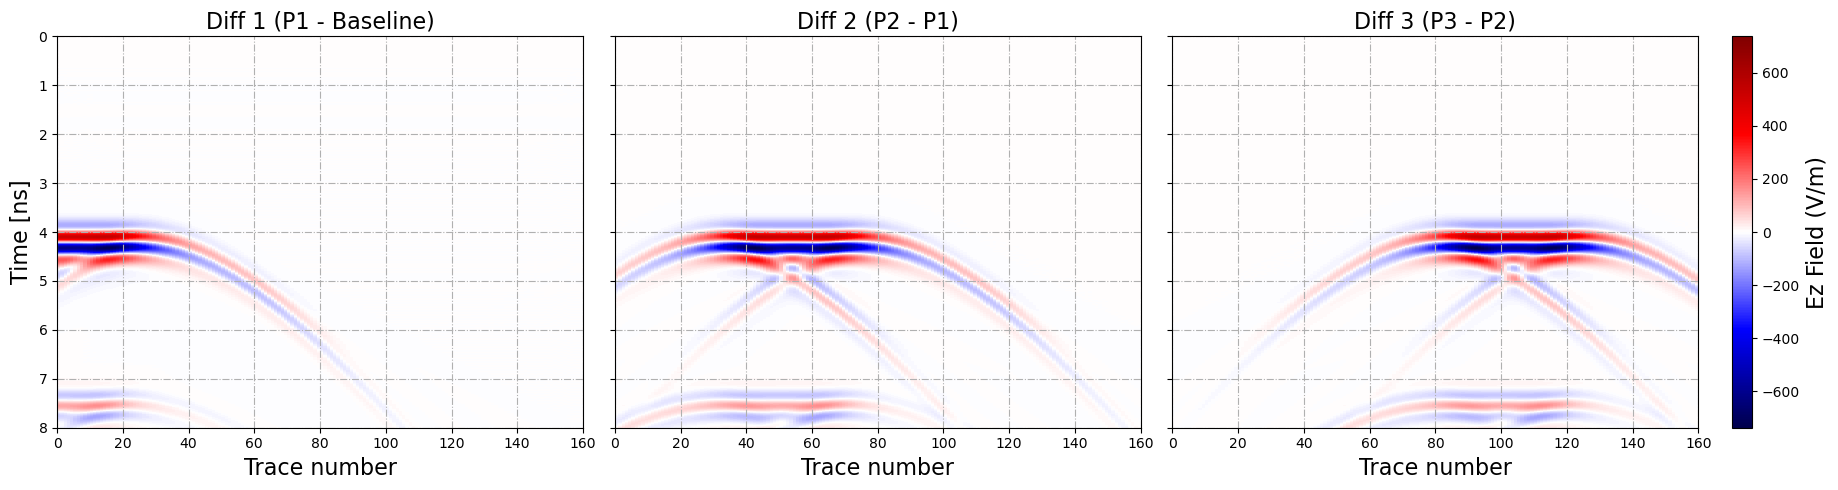

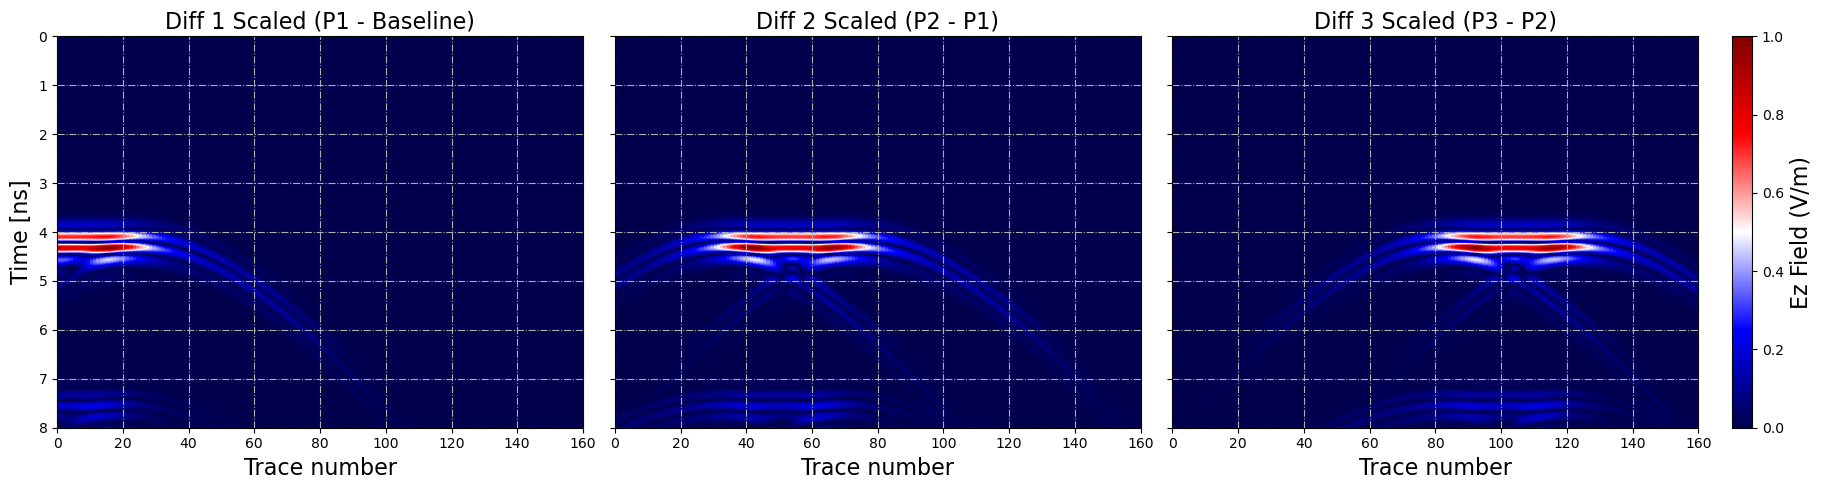

In [117]:

# Plotting: Scaled time-lapse differences (diff_1, diff_2, diff_3)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='w', edgecolor='w', sharex=True, sharey=True)

diff_data = [
    ("Diff 1 (P1 - Baseline)", diff_1),
    ("Diff 2 (P2 - P1)",       diff_2),
    ("Diff 3 (P3 - P2)",       diff_3),
]

diff_scaled_data = [
    ("Diff 1 Scaled (P1 - Baseline)", diff_1_scaled),
    ("Diff 2 Scaled (P2 - P1)",       diff_2_scaled),
    ("Diff 3 Scaled (P3 - P2)",       diff_3_scaled),
]

# compute common color scaling for unscaled differences
vmin_diff = -np.amax([np.abs(d).max() for _, d in diff_data])
vmax_diff =  np.amax([np.abs(d).max() for _, d in diff_data])

# Plot unscaled differences
for i, (title, data) in enumerate(diff_data):
    ax = axes[i]
    im = ax.imshow(data, aspect='auto', cmap='seismic', extent=extent, interpolation='nearest', vmin=vmin_diff, vmax=vmax_diff)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Trace number', fontsize=16)
    if i == 0:
        ax.set_ylabel('Time [ns]', fontsize=16)
    ax.grid(which='both', axis='both', linestyle='-.')

plt.tight_layout()
cbar1 = fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02)
cbar1.set_label('Ez Field (V/m)', fontsize=16)


# save image
path = 'Images_Experiment_9\\Results\\Processing\\Time_Lapse_Differences_Unscaled.png'
plt.savefig(fname = path, bbox_inches='tight')

plt.show()

# Plot scaled differences in a separate figure
fig2, axes2 = plt.subplots(1, 3, figsize=(18, 5), facecolor='w', edgecolor='w', sharex=True, sharey=True)
for i, (title, data) in enumerate(diff_scaled_data):
    ax = axes2[i]
    im2 = ax.imshow(data, aspect='auto', cmap='seismic', extent=extent, interpolation='nearest')
    ax.set_title(title, fontsize=16)
    ax.set_xlabel('Trace number', fontsize=16)
    if i == 0:
        ax.set_ylabel('Time [ns]', fontsize=16)
    ax.grid(which='both', axis='both', linestyle='-.')

plt.tight_layout()
cbar2 = fig2.colorbar(im2, ax=axes2, fraction=0.02, pad=0.02)
cbar2.set_label('Ez Field (V/m)', fontsize=16)

# save image
path2 = 'Images_Experiment_9\\Results\\Processing\\Time_Lapse_Differences_Scaled.png'
plt.savefig(fname = path2, bbox_inches='tight')

plt.show()

Polarity Change

In [109]:
# Remove direct wave: output - background
baseline_no_direct  = output_infinite_fracture_baseline  - output_infinite_fracture_background
process_1_no_direct = output_infinite_fracture_process_1 - output_infinite_fracture_background
process_2_no_direct = output_infinite_fracture_process_2 - output_infinite_fracture_background
process_3_no_direct = output_infinite_fracture_process_3 - output_infinite_fracture_background

# time-lapse differences
diff_1 = process_1_no_direct - baseline_no_direct
diff_2 = process_2_no_direct - process_1_no_direct
diff_3 = process_3_no_direct - process_2_no_direct

# Extra: Pyvista visualisation

In [48]:
import pyvista as pv

vti_background = r'C:\Users\Administrator\OneDrive\Data B\School\GP2\Research Project\GPRMax\Experiment_9\infinite_fracture_background.vti'
vti_baseline   = r'C:\Users\Administrator\OneDrive\Data B\School\GP2\Research Project\GPRMax\Experiment_9\infinite_fracture_baseline.vti'
vti_process_1  = r'C:\Users\Administrator\OneDrive\Data B\School\GP2\Research Project\GPRMax\Experiment_9\infinite_fracture_process_1.vti'
vti_process_2  = r'C:\Users\Administrator\OneDrive\Data B\School\GP2\Research Project\GPRMax\Experiment_9\infinite_fracture_process_2.vti'
vti_process_3  = r'C:\Users\Administrator\OneDrive\Data B\School\GP2\Research Project\GPRMax\Experiment_9\infinite_fracture_process_3.vti'

# Read all meshes
mesh_background = pv.read(vti_background)
mesh_baseline   = pv.read(vti_baseline)
mesh_process_1  = pv.read(vti_process_1)
mesh_process_2  = pv.read(vti_process_2)
mesh_process_3  = pv.read(vti_process_3)


c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


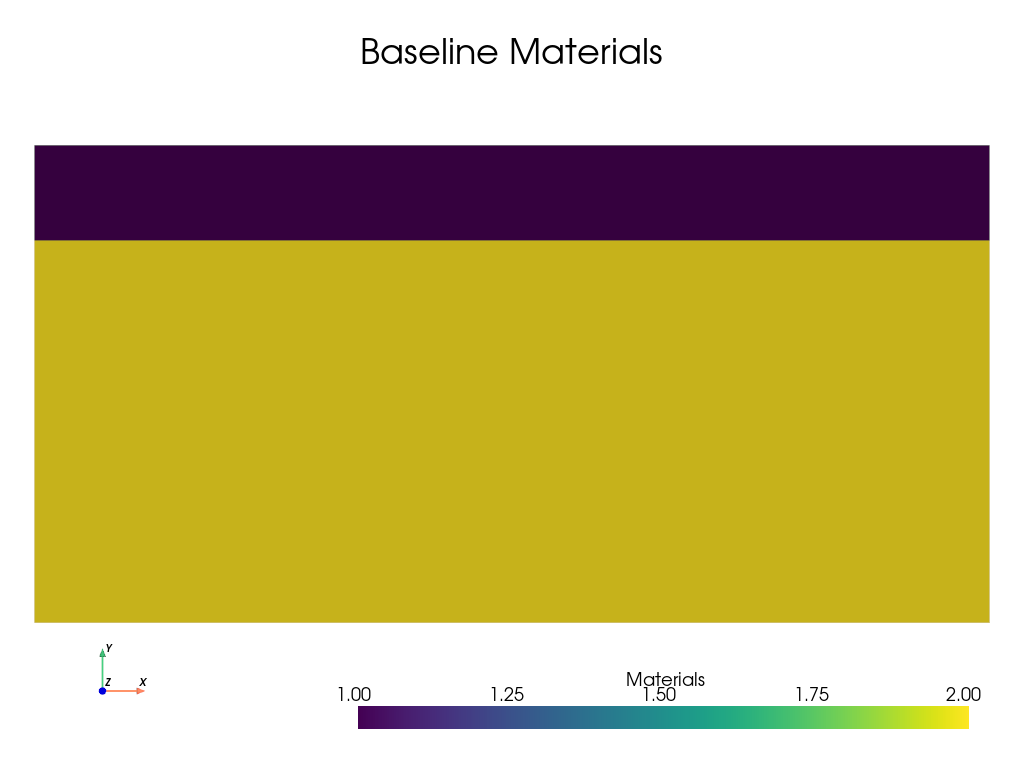

In [49]:

# Create a 1x1 plotter
plotter = pv.Plotter(shape=(1, 1))

# Camera position: (position, focal_point, view_up)
camera_pos = [(0.5, 0.25, 1.5), (0.5, 0.25, 0), (0, 1, 0)]

# Plot: Materials
plotter.subplot(0, 0)
plotter.add_mesh(mesh_background, scalars='Material', cmap='viridis', show_scalar_bar=True,
                 scalar_bar_args={'title': 'Materials'})
plotter.camera_position = camera_pos
plotter.add_title("Baseline Materials", font_size=14, color='black')
plotter.add_axes()
plotter.show()


c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


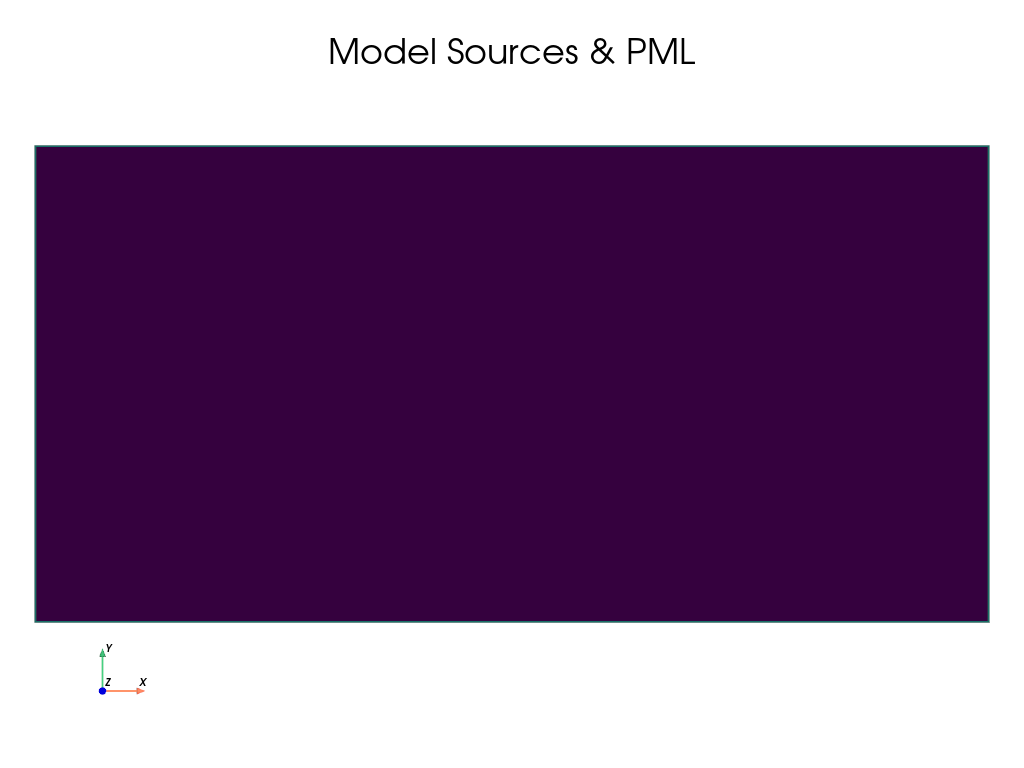

In [50]:

# Create a 1x1 plotter
plotter = pv.Plotter(shape=(1, 1))

# Camera position: (position, focal_point, view_up)
camera_pos = [(0.5, 0.25, 1.5), (0.5, 0.25, 0), (0, 1, 0)]

# Plot: PML
plotter.subplot(0, 0)
plotter.add_mesh(mesh_baseline, scalars='Sources_PML', cmap='viridis', show_scalar_bar=False,
                 scalar_bar_args={'title': 'Sources & PML'})
plotter.camera_position = camera_pos
plotter.add_title("Model Sources & PML", font_size=14, color='black')
plotter.add_axes()
plotter.show()


c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\pyvista\jupyter\notebook.py:56: UserWarning: Failed to use notebook backend: 

cannot import name 'vtk' from 'trame.widgets' (c:\Users\Administrator\miniconda3\envs\gprMax\Lib\site-packages\trame\widgets\__init__.py)

Falling back to a static output.
  warnings.warn(


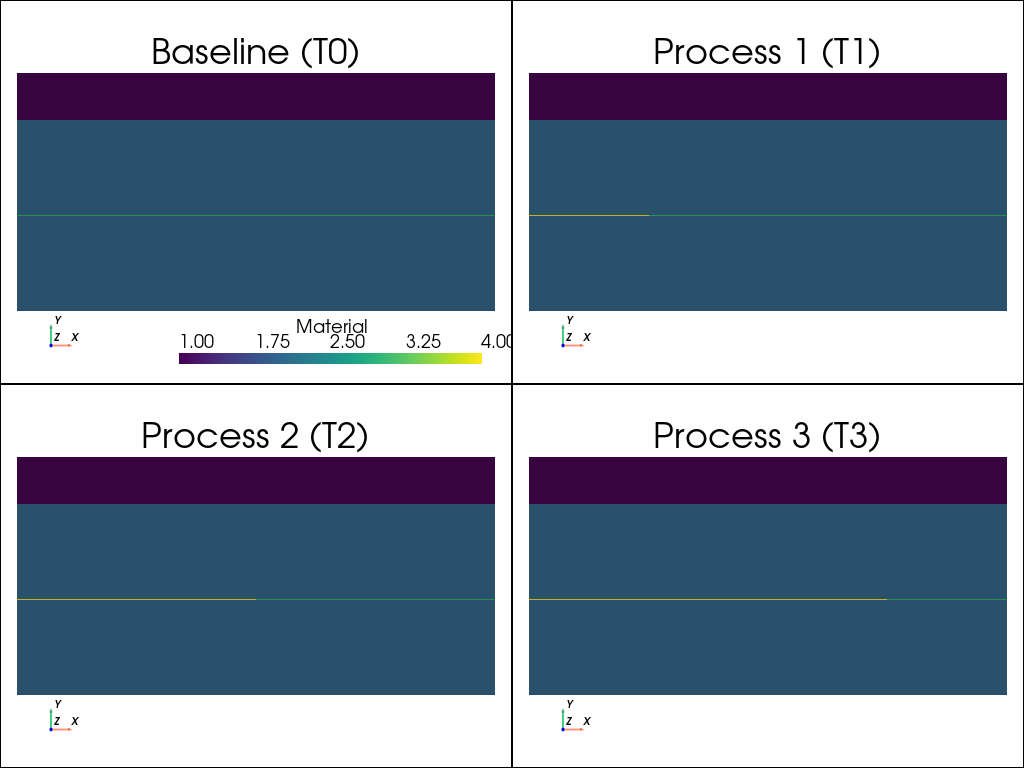

In [51]:
# Create a 2x2 plotter
plotter = pv.Plotter(shape=(2, 2))

# Camera position: (position, focal_point, view_up)
camera_pos = [(0.5, 0.25, 1.5), (0.5, 0.25, 0), (0, 1, 0)]

# Plot 1: Baseline
plotter.subplot(0, 0)
plotter.add_mesh(mesh_baseline, opacity=0.9, scalars='Material', cmap='viridis', show_scalar_bar=True)
plotter.camera_position = camera_pos
plotter.add_title("Baseline (T0)", font_size=14, color='black')
plotter.add_axes()

# Plot 2: Process 1
plotter.subplot(0, 1)
plotter.add_mesh(mesh_process_1, opacity=0.9, scalars='Material', cmap='viridis', show_scalar_bar=True)
plotter.camera_position = camera_pos
plotter.add_title("Process 1 (T1)", font_size=14, color='black')
plotter.add_axes()

# Plot 3: Process 2
plotter.subplot(1, 0)
plotter.add_mesh(mesh_process_2, opacity=0.9, scalars='Material', cmap='viridis', show_scalar_bar=True)
plotter.camera_position = camera_pos
plotter.add_title("Process 2 (T2)", font_size=14, color='black')
plotter.add_axes()

# Plot 4: Process 3
plotter.subplot(1, 1)
plotter.add_mesh(mesh_process_3, opacity=0.9, scalars='Material', cmap='viridis', show_scalar_bar=True)
plotter.camera_position = camera_pos
plotter.add_title("Process 3 (T3)", font_size=14, color='black')
plotter.add_axes()

plotter.show()

In [52]:
mesh

ImageData (0x215d004e3e0)
  N Cells:      12500000
  N Points:     25015002
  X Bounds:     0.000e+00, 1.000e+00
  Y Bounds:     0.000e+00, 5.000e-01
  Z Bounds:     0.000e+00, 2.000e-04
  Dimensions:   5001, 2501, 2
  Spacing:      2.000e-04, 2.000e-04, 2.000e-04
  N Arrays:     2